In [1]:
import torch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")


Using device: cuda
GPU: NVIDIA GeForce RTX 5070


In [2]:
from collections import Counter
from pathlib import Path
import random
import re

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import torch
import torch.nn as nn
from sklearn.metrics import accuracy_score, classification_report
from sklearn.model_selection import train_test_split
from torch.utils.data import DataLoader, Dataset

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")

BASE_DIR = Path.cwd()
DATASET_PATH = BASE_DIR / "Dataset source" / "training" / "Dataset_SMS_clean.csv"
MODEL_DIR = BASE_DIR / "Models" / "bilstm_spam_classifier"
MODEL_PATH = MODEL_DIR / "bilstm_model.pt"
VOCAB_PATH = MODEL_DIR / "vocab.joblib"
TEST_SIZE = 0.2
RANDOM_STATE = 42
MAX_VOCAB_SIZE = 20000
MAX_LENGTH = 80
EMBED_DIM = 128
HIDDEN_DIM = 128
BATCH_SIZE = 64
EPOCHS = 5
LEARNING_RATE = 1e-3

random.seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)
torch.manual_seed(RANDOM_STATE)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(RANDOM_STATE)

df = pd.read_csv(DATASET_PATH, encoding="utf-8-sig")
df = df.dropna(subset=["Category", "Message"]).copy()
df["Category"] = df["Category"].astype(str).str.strip().str.lower()
df["Message"] = df["Message"].astype(str).str.strip()
df = df[df["Category"].isin(["ham", "spam"])]
df = df[df["Message"] != ""]

token_pattern = re.compile(r"[A-Za-z0-9']+")

def tokenize(text):
    return token_pattern.findall(str(text).lower())

df = df[df["Message"].apply(lambda text: len(tokenize(text)) > 0)].copy()
df["label"] = df["Category"].map({"ham": 0, "spam": 1})

train_df, test_df = train_test_split(
    df[["Message", "Category", "label"]],
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    stratify=df["label"],
)

counter = Counter()
for text in train_df["Message"]:
    counter.update(tokenize(text))

special_tokens = ["<PAD>", "<UNK>"]
most_common_tokens = [token for token, _ in counter.most_common(MAX_VOCAB_SIZE - len(special_tokens))]
vocab = {token: idx for idx, token in enumerate(special_tokens + most_common_tokens)}
pad_idx = vocab["<PAD>"]
unk_idx = vocab["<UNK>"]

def encode_text(text, vocab, max_length):
    tokens = tokenize(text)
    token_ids = [vocab.get(token, unk_idx) for token in tokens[:max_length]]
    if not token_ids:
        token_ids = [pad_idx]
    length = len(token_ids)
    if length < max_length:
        token_ids += [pad_idx] * (max_length - length)
    return token_ids, max(1, min(length, max_length))

class TextDataset(Dataset):
    def __init__(self, dataframe, vocab, max_length):
        self.texts = dataframe["Message"].tolist()
        self.labels = dataframe["label"].tolist()
        self.vocab = vocab
        self.max_length = max_length

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        token_ids, length = encode_text(self.texts[idx], self.vocab, self.max_length)
        return {
            "input_ids": torch.tensor(token_ids, dtype=torch.long),
            "length": torch.tensor(length, dtype=torch.long),
            "label": torch.tensor(self.labels[idx], dtype=torch.long),
        }

train_dataset = TextDataset(train_df.reset_index(drop=True), vocab, MAX_LENGTH)
test_dataset = TextDataset(test_df.reset_index(drop=True), vocab, MAX_LENGTH)
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

class BiLSTMClassifier(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_dim, pad_idx):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=pad_idx)
        self.lstm = nn.LSTM(
            input_size=embed_dim,
            hidden_size=hidden_dim,
            batch_first=True,
            bidirectional=True,
        )
        self.dropout = nn.Dropout(0.3)
        self.fc = nn.Linear(hidden_dim * 2, 2)

    def forward(self, input_ids, lengths):
        embedded = self.embedding(input_ids)
        packed = nn.utils.rnn.pack_padded_sequence(
            embedded,
            lengths.cpu(),
            batch_first=True,
            enforce_sorted=False,
        )
        _, (hidden, _) = self.lstm(packed)
        forward_hidden = hidden[-2]
        backward_hidden = hidden[-1]
        features = torch.cat((forward_hidden, backward_hidden), dim=1)
        return self.fc(self.dropout(features))

model = BiLSTMClassifier(len(vocab), EMBED_DIM, HIDDEN_DIM, pad_idx).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)

history = []

def run_epoch(model, data_loader, criterion, optimizer=None):
    is_train = optimizer is not None
    model.train() if is_train else model.eval()
    total_loss = 0.0
    predictions = []
    labels = []

    with torch.set_grad_enabled(is_train):
        for batch in data_loader:
            input_ids = batch["input_ids"].to(device)
            lengths = batch["length"].to(device)
            batch_labels = batch["label"].to(device)

            logits = model(input_ids, lengths)
            loss = criterion(logits, batch_labels)

            if is_train:
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()

            total_loss += loss.item() * batch_labels.size(0)
            predictions.extend(torch.argmax(logits, dim=1).detach().cpu().numpy())
            labels.extend(batch_labels.detach().cpu().numpy())

    avg_loss = total_loss / len(data_loader.dataset)
    accuracy = accuracy_score(labels, predictions)
    return avg_loss, accuracy, labels, predictions

for epoch in range(1, EPOCHS + 1):
    train_loss, train_accuracy, _, _ = run_epoch(model, train_loader, criterion, optimizer)
    eval_loss, eval_accuracy, y_true, y_pred = run_epoch(model, test_loader, criterion)
    history.append(
        {
            "epoch": epoch,
            "train_loss": train_loss,
            "train_accuracy": train_accuracy,
            "eval_loss": eval_loss,
            "eval_accuracy": eval_accuracy,
        }
    )
    print(
        f"Epoch {epoch}/{EPOCHS} | "
        f"Train Loss: {train_loss:.4f} | Train Acc: {train_accuracy:.4f} | "
        f"Eval Loss: {eval_loss:.4f} | Eval Acc: {eval_accuracy:.4f}"
    )

history_df = pd.DataFrame(history)
report_df = pd.DataFrame(
    classification_report(
        test_df["Category"],
        ["spam" if pred == 1 else "ham" for pred in y_pred],
        output_dict=True,
    )
).transpose()

MODEL_DIR.mkdir(parents=True, exist_ok=True)
torch.save(model.state_dict(), MODEL_PATH)
joblib.dump(
    {
        "vocab": vocab,
        "pad_idx": pad_idx,
        "unk_idx": unk_idx,
        "max_length": MAX_LENGTH,
        "embed_dim": EMBED_DIM,
        "hidden_dim": HIDDEN_DIM,
    },
    VOCAB_PATH,
)

train_accuracy = history_df.iloc[-1]["train_accuracy"]
test_accuracy = history_df.iloc[-1]["eval_accuracy"]

print(f"Training samples: {len(train_df)}")
print(f"Test samples: {len(test_df)}")
print(f"Training accuracy: {train_accuracy:.4f}")
print(f"Test accuracy: {test_accuracy:.4f}")
print(device)



Using device: cuda
GPU: NVIDIA GeForce RTX 5070
Epoch 1/5 | Train Loss: 0.2963 | Train Acc: 0.8983 | Eval Loss: 0.1447 | Eval Acc: 0.9553
Epoch 2/5 | Train Loss: 0.0795 | Train Acc: 0.9767 | Eval Loss: 0.0932 | Eval Acc: 0.9709
Epoch 3/5 | Train Loss: 0.0276 | Train Acc: 0.9939 | Eval Loss: 0.1000 | Eval Acc: 0.9699
Epoch 4/5 | Train Loss: 0.0113 | Train Acc: 0.9978 | Eval Loss: 0.1437 | Eval Acc: 0.9553
Epoch 5/5 | Train Loss: 0.0047 | Train Acc: 0.9998 | Eval Loss: 0.1284 | Eval Acc: 0.9689
Training samples: 4119
Test samples: 1030
Training accuracy: 0.9998
Test accuracy: 0.9689
cuda


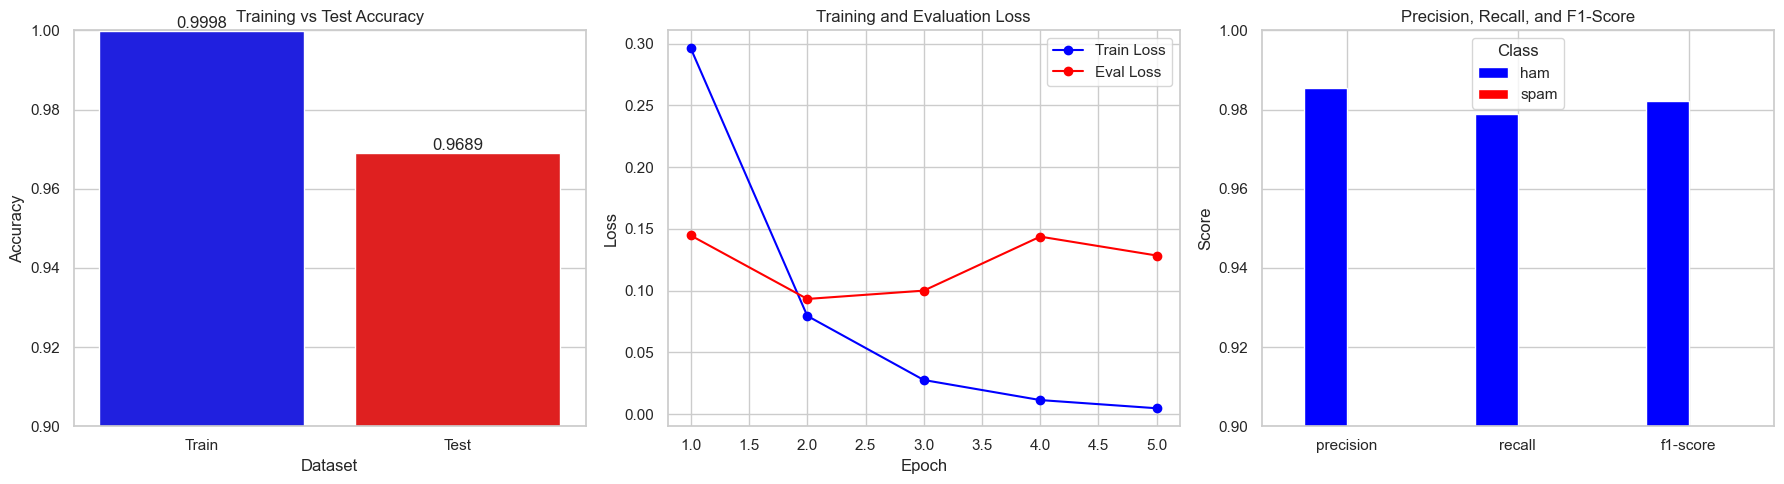

,precision,recall,f1-score,support
ham,0.985491,0.978936,0.982202,902.000000
spam,0.858209,0.898438,0.877863,128.000000
accuracy,0.968932,0.968932,0.968932,0.968932
macro avg,0.921850,0.938687,0.930033,1030.000000
weighted avg,0.969673,0.968932,0.969236,1030.000000


In [3]:
sns.set_theme(style="whitegrid")

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

accuracy_df = pd.DataFrame({
    "Dataset": ["Train", "Test"],
    "Accuracy": [train_accuracy, test_accuracy],
})
sns.barplot(data=accuracy_df, x="Dataset", y="Accuracy", hue="Dataset", palette=["blue", "red"], ax=axes[0], legend=False)
axes[0].set_ylim(0.9, 1.0)
axes[0].set_title("Training vs Test Accuracy")
axes[0].set_ylabel("Accuracy")
for container in axes[0].containers:
    axes[0].bar_label(container, fmt="%.4f")

axes[1].plot(history_df["epoch"], history_df["train_loss"], marker="o", color="blue", label="Train Loss")
axes[1].plot(history_df["epoch"], history_df["eval_loss"], marker="o", color="red", label="Eval Loss")
axes[1].set_title("Training and Evaluation Loss")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Loss")
axes[1].legend()

metrics_df = report_df.loc[["ham", "spam"], ["precision", "recall", "f1-score"]].transpose()
metrics_df.plot(kind="bar", ax=axes[2], color=["blue", "red"])
axes[2].set_ylim(0.9, 1.0)
axes[2].set_title("Precision, Recall, and F1-Score")
axes[2].set_ylabel("Score")
axes[2].tick_params(axis="x", rotation=0)
axes[2].legend(title="Class")

plt.tight_layout()
plt.show()

report_df


In [5]:
from pathlib import Path

import joblib
import torch

BASE_DIR = Path.cwd()
MODEL_DIR = BASE_DIR / "Models" / "bilstm_spam_classifier"
MODEL_PATH = MODEL_DIR / "bilstm_model.pt"
VOCAB_PATH = MODEL_DIR / "vocab.joblib"
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

saved_artifacts = joblib.load(VOCAB_PATH)
vocab = saved_artifacts["vocab"]
pad_idx = saved_artifacts["pad_idx"]
unk_idx = saved_artifacts["unk_idx"]
max_length = saved_artifacts["max_length"]
embed_dim = saved_artifacts["embed_dim"]
hidden_dim = saved_artifacts["hidden_dim"]

class BiLSTMClassifier(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_dim, pad_idx):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=pad_idx)
        self.lstm = nn.LSTM(embed_dim, hidden_dim, batch_first=True, bidirectional=True)
        self.dropout = nn.Dropout(0.3)
        self.fc = nn.Linear(hidden_dim * 2, 2)

    def forward(self, input_ids, lengths):
        embedded = self.embedding(input_ids)
        packed = nn.utils.rnn.pack_padded_sequence(embedded, lengths.cpu(), batch_first=True, enforce_sorted=False)
        _, (hidden, _) = self.lstm(packed)
        features = torch.cat((hidden[-2], hidden[-1]), dim=1)
        return self.fc(self.dropout(features))

token_pattern = re.compile(r"[A-Za-z0-9']+")

def tokenize(text):
    return token_pattern.findall(str(text).lower())

def encode_text(text):
    tokens = tokenize(text)
    token_ids = [vocab.get(token, unk_idx) for token in tokens[:max_length]]
    length = len(token_ids)
    if length < max_length:
        token_ids += [pad_idx] * (max_length - length)
    return token_ids, min(length, max_length)

model = BiLSTMClassifier(len(vocab), embed_dim, hidden_dim, pad_idx).to(device)
model.load_state_dict(torch.load(MODEL_PATH, map_location=device))
model.eval()

# test_text = "Congratulations! You have won a free prize. Reply now to claim it."
#test_text = "Congrats! Youve been selected for a remote task role. Earn daily income by rating hotels. Start today!"
test_text = "Dear Customer your pyatm wallet Has been booked and hold Your amount please complete your kyc contact customer care 7044518857"

token_ids, length = encode_text(test_text)
input_ids = torch.tensor([token_ids], dtype=torch.long).to(device)
lengths = torch.tensor([max(length, 1)], dtype=torch.long).to(device)

with torch.no_grad():
    logits = model(input_ids, lengths)
    prediction = torch.argmax(logits, dim=1).item()

print("spam" if prediction == 1 else "ham")


spam
